In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import binom, norm
from statsmodels.stats.proportion import proportions_ztest


import matplotlib.pyplot as plt
import seaborn as sns

import pickle
import sys

sys.path.append('../src')
from discipline_stats import (
    filter_league_season,
    team_summary,
    rate_summary,
    plot_league_bar,
    plot_forest,
    compare_mean_to_threshold
)

In [2]:
with open('../data/processed/team_matches.pkl', 'rb') as f:
    team_matches = pickle.load(f)

serie_a_2425 = team_matches[
    (team_matches['league'] == 'Serie_A') &
    (team_matches['season'] == '2425')
].copy()

print(f"Rows: {len(serie_a_2425):,}")
print(f"Teams: {serie_a_2425['team'].nunique()}")
print(f"Matches per team: {len(serie_a_2425) // serie_a_2425['team'].nunique()}")

Rows: 760
Teams: 20
Matches per team: 38


In [3]:
# all_2425 = team_matches[
#     team_matches['season'] == '2425'
# ].copy()

# print(f"Rows: {len(all_2425):,}")
# print(f"Leagues: {all_2425['league'].nunique()}")

# The Foul, the Card, the Gap

*Not all fouls are created equal. Some are more equal than others.*

## Previously on

In previous notebooks of this series we analysed [fouls committed](https://github.com/pacoraggio/euro-football-discipline-stats/blob/master/notebooks/03_fouls_analysis.ipynb) and [yellow cards](https://github.com/pacoraggio/euro-football-discipline-stats/blob/master/notebooks/04_yellow_cards_analysis.ipynb) received as separate quantities, using Serie A 2024/25 as our working example. We found that some teams foul significantly more than the league average, and that some teams receive significantly more yellow cards. We also found that the two rankings do not always match.

The scatter plot at the end of the yellow cards notebook made this visible: some teams foul a lot and get relatively few cards, while others foul little and collect many bookings. The two metrics tell different stories about the same matches.

This notebook investigates the gap between them: not how much a team fouls, and not how many cards it receives, but the rate at which fouls become bookings. That rate is the metric that connects the two analyses and, as we will see, measuring it carefully turns out to be less straightforward than it looks.

If you are reading this notebook without the previous ones, all you need to know is this: a team commits roughly 12 fouls per match in Serie A and receives roughly 2 yellow cards. The question is whether that ratio is the same for every team, or whether some teams are systematically more or less likely to be booked for the same foul.

## Why this metric, and why it is not simple

The most natural way to connect fouls and yellow cards is to ask: out of every foul committed, how often does the referee reach for a card? This is the **conversion rate**, and it has an immediate intuitive appeal. A team that fouls aggressively but rarely gets booked is playing a different game from a team that commits fewer but more reckless challenges. The raw counts cannot tell those stories apart. The rate can.

But the rate is not a neutral measurement. It is a compound of at least three things: how a team plays, how the referee interprets the laws of the game, and the interaction between the two. Before we compute anything, it is worth being precise about what the metric can and cannot tell us.

**Within a single league and season**, the referee pool is roughly shared. Every team faces the same set of officials over 38 matches, with some rotation. Systematic differences in the rate between teams are therefore more likely to reflect team behaviour than referee behaviour. A team with a consistently high conversion rate across many different referees is probably doing something that earns cards regardless of who is officiating.

**Across different leagues**, the picture is more complicated. We already showed in the fouls notebook that Italian referees call nearly three more fouls per match than English ones, while the number of yellow cards per match is almost identical in both leagues. This means the denominator of our rate, fouls committed, is itself referee-dependent. A higher conversion rate in one league might mean referees apply a stricter threshold for showing a card, or it might mean the fouls being called are of a different nature: softer, more frequent, less card-worthy. The metric cannot separate these explanations on its own.

The honest summary: within a league, the rate is primarily a team signal. Across leagues, it is a compound of team behaviour and referee culture, and interpreting it requires care.

This notebook focuses on the within-league question first. We will move to the cross-league comparison at the end, with the appropriate caveats. Future notebooks in the series will use multi-season and national versus international data to try to isolate the referee effect more cleanly.


## Two ways to measure the same thing

Before we run any tests, we need to decide how to compute the rate. This is not a technical detail. It is a measurement choice that affects every number that follows, and the two most natural approaches give different answers.

**Approach 1: ratio of totals (crude rate)**

Add up all the yellow cards a team received across the season. Divide by the total number of fouls committed. One number per team, computed from the season totals.

This is the simplest version of the metric and the easiest to communicate: Verona committed 475 fouls and received 94 yellow cards, so their conversion rate is 94/475 = 0.198, roughly one booking every five fouls.

**Approach 2: mean of per-match ratios**

For each match, compute the ratio of yellow cards to fouls committed. Then take the average of those match-level ratios across the season.

This treats each match as an independent observation. A match where a team commits 2 fouls and receives 1 yellow card contributes a ratio of 0.5, regardless of how many fouls the team commits in other matches.

**Why they differ**

The two approaches weight matches differently. The ratio of totals gives more weight to high-foul matches, because those matches contribute more to the denominator. The mean of per-match ratios treats every match equally regardless of how many fouls were committed.

Neither is universally correct. The ratio of totals is more stable and less sensitive to outlier matches with very few fouls. The mean of per-match ratios is more representative of the typical match experience but can be distorted by matches where the denominator is very small: a team that commits 1 foul and receives 1 yellow card contributes a ratio of 1.0, which may not be meaningful.

We will compute both, compare them, and choose one for the main analysis. The choice will be explicit and justified.

In [4]:
rate_df = rate_summary(serie_a_2425, numerator='yellow_cards', denominator='fouls_committed')
rate_df = rate_df.sort_values('ratio_of_totals', ascending=False).reset_index(drop=True)

rate_df['fouls_per_card_total'] = rate_df['total_denominator'] / rate_df['total_numerator']
rate_df['fouls_per_card_mean']  = 1 / rate_df['mean_ratio']

print(f"League totals: {serie_a_2425['yellow_cards'].sum():.0f} yellow cards, "
      f"{serie_a_2425['fouls_committed'].sum():.0f} fouls")
print(f"League crude rate: "
      f"{serie_a_2425['yellow_cards'].sum() / serie_a_2425['fouls_committed'].sum():.4f} - inverse: { serie_a_2425['fouls_committed'].sum() /serie_a_2425['yellow_cards'].sum():.4f}\n")

print(rate_df[['team', 'total_numerator', 'total_denominator',
               'ratio_of_totals', 'fouls_per_card_total',
               'mean_ratio', 'fouls_per_card_mean']].to_string(index=False))


League totals: 1452 yellow cards, 9501 fouls
League crude rate: 0.1528 - inverse: 6.5434

      team  total_numerator  total_denominator  ratio_of_totals  fouls_per_card_total  mean_ratio  fouls_per_card_mean
     Lazio             92.0              424.0         0.216981              4.608696    0.218175             4.583474
Fiorentina             81.0              440.0         0.184091              5.432099    0.211161             4.735713
     Parma             74.0              405.0         0.182716              5.472973    0.195564             5.113403
     Monza             90.0              511.0         0.176125              5.677778    0.182611             5.476116
      Como             87.0              497.0         0.175050              5.712644    0.186911             5.350130
    Torino             80.0              480.0         0.166667              6.000000    0.174943             5.716159
     Milan             68.0              415.0         0.163855              

The table also shows the inverse, i.e. fouls per card, which is often easier to read: Lazio concedes a booking every 4.6 fouls; Napoli, every 9.4.

The two approaches agree closely for most teams: the ratio of totals and the mean of per-match ratios differ by no more than 0.01 for the majority. This is reassuring. When the two methods give similar answers, the measurement is stable and not sensitive to the choice of approach.

The league crude rate is 0.153: roughly one yellow card every six and a half fouls. But the team-level variation is substantial. Lazio converts one foul in every 4.6 into a booking (rate 0.217). Napoli converts one in every nine (rate 0.111). That is nearly a factor of two between the top and bottom of the table.

Notice something immediately: the rate ranking looks very different from the fouls ranking. Lazio was one of the least fouling teams in the league. Empoli and Bologna were among the most fouling. Yet here, Lazio sits at the top and Empoli and Bologna sit near the bottom. The scatter plot anomaly we identified in the yellow cards notebook is now a number.

The two measurement approaches differ most for Fiorentina (0.184 vs 0.211) and Napoli (0.111 vs 0.106). For Fiorentina, the mean of per-match ratios is higher, suggesting that in matches where they committed few fouls, a higher proportion became cards. For Napoli, the ratio of totals (0.111) is marginally higher than the mean of per-match ratios (0.106), suggesting that in matches where they committed more fouls, a slightly higher proportion became cards. Both differences are small and may simply reflect match-to-match variation rather than a systematic pattern.

For the main analysis we will use the **ratio of totals**. It is more stable, less sensitive to low-foul matches, and easier to interpret as a season-level summary. We keep the mean of per-match ratios available for comparison.

## Visualizing the rate

Before running any tests, we look at the rate visually. The bar chart shows each team's conversion rate relative to the league average, using the ratio of totals. The scatter plot anomalies from the previous notebook should now have a clear numerical form.

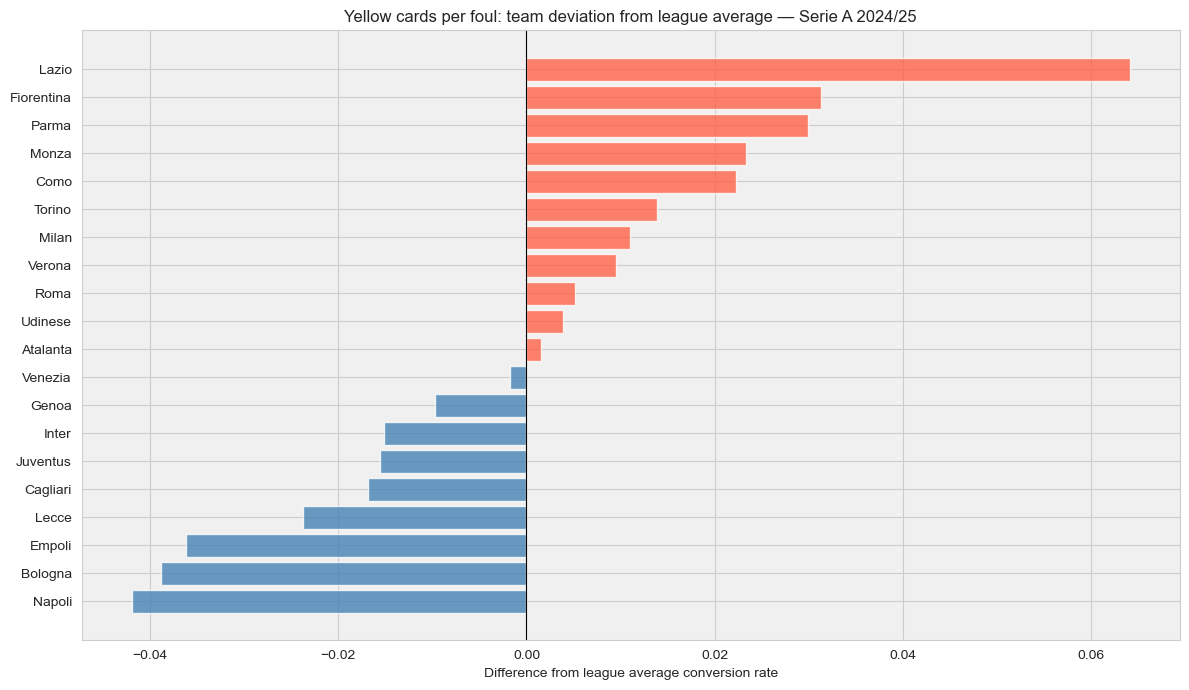

League average conversion rate: 0.1528


In [5]:
import matplotlib.patches as mpatches

league_rate = serie_a_2425['yellow_cards'].sum() / serie_a_2425['fouls_committed'].sum()
rate_df['diff_from_league'] = rate_df['ratio_of_totals'] - league_rate

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.set_facecolor('#f0f0f0')

    colors = ['tomato' if x > 0 else 'steelblue' for x in rate_df['diff_from_league']]

    ax.barh(rate_df['team'], rate_df['diff_from_league'], color=colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Difference from league average conversion rate')
    ax.set_title('Yellow cards per foul: team deviation from league average — Serie A 2024/25')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

print(f"League average conversion rate: {league_rate:.4f}")


The chart tells a cleaner story than either the fouls or yellow cards charts did individually.

Lazio stands alone at the top, more than 0.06 above the league average. That is not a small gap: the league average rate is 0.153, and Lazio sits at 0.217. They are converting fouls into bookings at a rate roughly 40% above the league norm.

Fiorentina and Parma follow, both around 0.03 above average. Then a cluster of teams between 0.01 and 0.025 above: Monza, Como, Torino, Milan, Verona. At the other end, Napoli, Bologna and Empoli sit furthest below the line, all more than 0.035 below average.

If we compare this ranking to the [fouls ranking from the same season and leauge](https://github.com/pacoraggio/euro-football-discipline-stats/blob/master/notebooks/03_fouls_analysis.ipynb), Verona was the most fouling team in the league. Here they sit in the middle of the pack. Lazio was one of the least fouling teams. Here they lead. The rate is doing exactly what it was designed to do: separating how much a team fouls from how often those fouls escalate.

The visual is suggestive. But a bar chart shows differences, not significance. The question is whether these gaps are real in the statistical sense, or whether they fall within the range of what random variation can produce over a 38-match season. That is what the tests are for.

## The statistical problem: why the tools we have are not enough

When dealing with fouls, their distribution allowed us to use t-tests for hypothesis testing. With yellow cards, the data turned out to be non-normal, so we added Mann-Whitney and permutation tests. Each time, the data forced us to upgrade the toolkit.

The rate presents a different problem.

A conversion rate is not a mean of continuous measurements. It is a proportion: out of a total of $n$ fouls, $k$ resulted in a yellow card. The simplest model for this kind of data is the ***binomial distribution***, not the Gaussian, and it is a reasonable place to start. The Poisson, which served us well for modelling yellow card counts, is not the right tool here: it models the number of events in a fixed interval with no upper bound, whereas the binomial models successes out of a fixed number of trials. We have a fixed number of trials. We know $n$. A team committed 424 fouls and received 92 yellow cards. We want to know whether a conversion rate of 92/424 = 0.217 is surprising given that the league average is 0.153.

This is a different question from "is this team's mean foul count different from the rest?" It is asking whether a particular number of successes in a fixed number of trials is consistent with a given underlying probability. The t-test was not designed for this. Mann-Whitney was not designed for this either: it compares rank orderings, not binomial outcomes.

We need proportion tests. There are two main ones, and they approach the same question from different angles.

The **z-test for proportions** uses a normal approximation: when $n$ is large enough, the binomial distribution is approximately Gaussian, and we can compute a standard error and a z-score. Fast, simple, and accurate when $n$ is large and $p$ is not too close to 0 or 1.

The **exact binomial test** makes no normal approximation. It computes the exact probability of observing $k$ or more successes in $n$ trials under the null hypothesis. Slower to compute, but exact. Preferred when $n$ is small or $p$ is extreme.

We will use both, compare them, and introduce bootstrap as a third verification. The pattern by now should be familiar: when multiple approaches agree, the conclusion is solid.

## Proportion tests: building the intuition

### A brief and not entirely unjustified historical detour

We have already met a brewer (Gosset), a chemist (Wilcoxon), an esteemed math professor (Henry Mann) and his doctoral student (Whitney, who did most of the work and got second billing on the paper, as doctoral students do). The proportion test has a less colourful origin story, but an older one.

The foundations of proportion testing trace back to [Pierre-Simon Laplace](https://en.wikipedia.org/wiki/Pierre-Simon_Laplace), a man whose talent for surviving political upheaval was, if anything, slightly more impressive than his talent for mathematics. Laplace worked through the French Revolution, the Terror, Napoleon's rise and fall, and the Restoration without ever finding himself on the wrong side of whoever was currently in power. Fourier, who knew him well, reportedly described him as a weathervane. Between regime changes, he found time to build a rigorous theory of probability.

Among other things, Laplace used what we would now recognise as a z-test for proportions to analyse birth records in Paris and London, asking whether the observed ratio of male to female births was consistent with an equal underlying probability. It was not, and Laplace was precise about the uncertainty in his conclusion. This was 1778. The mathematics had nothing to do with politics, which was presumably a relief.

The exact binomial test has an even older pedigree. [Jacob Bernoulli](https://en.wikipedia.org/wiki/Jacob_Bernoulli) described the binomial distribution in his *Ars Conjectandi*, published posthumously in 1713. Bernoulli spent twenty years working on it and died before it was finished. The idea that you could compute the exact probability of $k$ successes in $n$ independent trials with fixed probability $p$ was one of the foundational results of probability theory. It took twenty years and one death to get there, which in retrospect seems like a lot for something that fits in half a line of code.

So the tools we are about to use are older than the t-test by more than a century. They were developed not for football data but for the same reason all statistical tools were developed: someone had a real question, imperfect data, and needed a principled way to separate signal from noise.

### The model and the reality: each foul is a Bernoulli trial

Start with the simplest possible experiment: a coin flip. Two outcomes, one probability. Call heads a success and tails a failure. The probability of success is $p = 0.5$, and nothing requires it to stay there. A biased coin with $p = 0.3$ is still a Bernoulli trial. So is a coin with $p = 0.1528$.

That last number is the Serie A 2024/25 conversion rate. A foul is a Bernoulli trial where success means a yellow card. The referee either reaches for the card or does not.

Before writing down the model formally, it is worth reminding ***what a model is***. In statistics as in physics, a model is always an approximation of reality. The binomial model says that each of Lazio's 424 fouls is an independent flip of the same biased coin, with a fixed probability $p$ of producing a card. We know this is not literally true. The probability that a foul becomes a card depends on the referee, the scoreline, the match situation, whether the player argues, and half a dozen other things. $p$ is not constant. The fouls are not independent.

And yet the model is useful. When we aggregate across a full season, 38 matches and hundreds of fouls, the noise from all those varying conditions averages out. What remains is a stable rate. The model is wrong at the level of individual fouls and approximately right at the level of the season. This is a recurring pattern in the series: events that are part of a messy, entangled process turn out to be well described by a model that assumes independence. It is not obvious that this should work. It does, and the rest of this notebook shows how far it takes us.

Under this model, a team that commits $n$ fouls and receives $k$ yellow cards has an observed rate $\hat{p} = k/n$, and the total number of cards follows a Binomial distribution:

$$K \sim \text{Binomial}(n,\ p)$$

A natural question at this point is whether the association between fouls and yellow cards can be measured directly, rather than assumed. At match level, a simple regression of cards on fouls committed would tell us whether matches with more fouls tend to produce more cards. We have everything we need for that. What we cannot do with this data is model the conversion probability of an individual foul, because we only observe match totals, not individual fouls. That would require a different dataset entirely: one row per foul, with features like the match situation, the referee, and the type of challenge. A logistic regression on that data would estimate how each feature shifts the probability of a card being issued. It would also show how much of the variation in conversion rates is explained by team behaviour versus referee tendency, which is exactly the decomposition we cannot make here. For now, the Bernoulli model with a fixed $p$ is the right level of complexity for the data we have.


### How the z-test for proportions works

The idea is straightforward. We have a team with a known number of fouls and yellow cards. We want to know whether their conversion rate is surprisingly different from the league average. We treat ***each foul as a trial***, and ***each yellow card as a success***.

Under the null hypothesis, the probability of a success on any given foul is equal to the league average rate $p = 0.153$. The question is: given that Lazio committed 424 fouls, how surprising is it to observe 92 yellow cards, i.e. an observed conversion rate of $\hat{p} = 0.217$?

The z-test answers this by computing how many standard deviations the observed rate sits away from the expected rate. The standard error of a proportion is:

$$SE = \sqrt{\frac{p(1-p)}{n}}$$

where $p$ is the null rate and $n$ is the number of trials (i.e. the number of fouls). The z-score is:

$$z = \frac{\hat{p} - p}{SE}$$

where $\hat{p}$ is the observed rate. If the absolute value of z is large, the observed rate is far from what we would expect by chance.

Let us compute this by hand for Lazio first, then verify with scipy.


In [6]:
from statsmodels.stats.proportion import proportions_ztest

# League reference rate
p_null = serie_a_2425['yellow_cards'].sum() / serie_a_2425['fouls_committed'].sum()

# Lazio's numbers
lazio = rate_df[rate_df['team'] == 'Lazio'].iloc[0]
n = int(lazio['total_denominator'])
k = int(lazio['total_numerator'])
p_hat = k / n

# Step 1: standard error
se = np.sqrt(p_null * (1 - p_null) / n)

# Step 2: z-score
z = (p_hat - p_null) / se

# Step 3: two-sided p-value
p_z = 2 * (1 - norm.cdf(abs(z)))

print(f"Lazio: {k} yellow cards in {n} fouls")
print(f"Observed rate:  {p_hat:.4f}")
print(f"League rate:    {p_null:.4f}")
print(f"Standard error: {se:.4f}")
print(f"z-score:        {z:.4f}")
print(f"p-value (z-test): {p_z:.4f}")
print()

# Verify with statsmodels
z_sm, p_sm = proportions_ztest(k, n, p_null)
print(f"statsmodels verification: z={z_sm:.4f}, p={p_sm:.4f}")

Lazio: 92 yellow cards in 424 fouls
Observed rate:  0.2170
League rate:    0.1528
Standard error: 0.0175
z-score:        3.6714
p-value (z-test): 0.0002

statsmodels verification: z=3.2049, p=0.0014


The manual calculation and statsmodels agree on the direction and significance but give different z-scores and p-values. This is worth understanding rather than glossing over.

Our calculation uses the null rate (0.153) in the standard error formula:

$$SE = \sqrt{\frac{p_0(1-p_0)}{n}}$$

This is the standard one-sample proportion test: we are asking how surprising the observed rate is if the true rate were the league average.

`statsmodels` library uses a slightly different convention by default, computing the standard error from the observed rate rather than the null rate. This is more common in two-sample tests where there is no fixed reference. For a one-sample test against a known reference rate, our manual version is the correct formulation.

Both return a highly significant result. Lazio's z-score of 3.67 means their observed rate sits nearly four standard deviations above the league average. The p-value of 0.0002 means that if the true rate were the league average, we would observe a deviation this large in fewer than 2 matches out of 10,000 seasons. The result is not on the boundary. It is emphatic.

Now let us run the exact binomial test as a verification, making no normal approximation at all.

In [7]:
p_binom = binom.sf(k - 1, n, p_null)
p_binom_twosided = min(1, 2 * p_binom)

print(f"Exact binomial test (one-sided):   p={p_binom:.4f}")
print(f"Exact binomial test (two-sided):   p={p_binom_twosided:.4f}")
print()

# scipy verification
result = stats.binomtest(k, n, p_null, alternative='two-sided')
print(f"scipy binomtest verification:      p={result.pvalue:.4f}")

Exact binomial test (one-sided):   p=0.0003
Exact binomial test (two-sided):   p=0.0006

scipy binomtest verification:      p=0.0004


Both the z-test and the exact binomial test agree: Lazio's conversion rate is highly significant. The exact binomial p-value of 0.0004 makes no normal approximation. It computes the exact probability of observing 92 or more yellow cards in 424 fouls if the true rate were the league average. That probability is very small.

The small discrepancy between our manual two-sided p-value (0.0006) and scipy's (0.0004) reflects a difference in how the two tails are summed. Our version doubles the one-sided p-value, which is a common approximation. Scipy sums all outcomes with probability at most as likely as the observed one in both directions, which is more precise. For results this far from the null, the difference is irrelevant. For borderline cases it can matter, which is a reason to prefer scipy's implementation in production.

The z-test and the exact binomial test tell the same story here, which is reassuring. The z-test is appropriate because n=424 is large and p=0.153 is not extreme, so the normal approximation is reliable. When n is small or p is close to 0 or 1, the exact binomial is the safer choice.

We now have the tools. Let us apply them to the full league.

## Bootstrap: building confidence from the data itself

The z-test and the exact binomial test both test against a fixed null rate: the league average. They answer the question "is this team's rate surprising given the league average?" But they say nothing about the uncertainty in the estimate itself. How wide is the range of plausible values for Lazio's true conversion rate? If we repeated the season with the same teams and referees, how much would the rate vary?

This is where the bootstrap comes in. Instead of deriving a confidence interval from a formula, we estimate it empirically by resampling the data we already have.

The idea is disarmingly simple. It is nor really "disarmingly simple", but using it makes you look smarter. 

Lazio played 38 matches. We treat those 38 matches as our best available description of Lazio's underlying behaviour. We then ask: if we reshuffled those 38 matches like a deck of cards, drew 38 again at random (with replacement, meaning the same match can appear more than once), and computed the conversion rate, what would we get? We repeat this thousands of times. Each repetition gives a slightly different rate, because each resample is a slightly different deck. The *distribution of those rates* is our empirical estimate of how much Lazio's rate *would vary* if the season were replayed with the same underlying behaviour.

The bootstrap makes no assumption about the shape of that distribution. It does not need the binomial approximation or the normal approximation. It just asks the data directly. One of its key advantages is that it quantifies how much the estimate would vary around its central value, with no assumptions required.

This is not the same as the permutation test introduced in [the yellow cards analysis](https://github.com/pacoraggio/euro-football-discipline-stats/blob/master/notebooks/04_yellow_cards_analysis.ipynb). The permutation test shuffled labels to test a null hypothesis. The bootstrap resamples from the observed data to estimate uncertainty. Both are resampling methods. They answer different questions. *The permutation test shuffled labels to test a null hypothesis. The bootstrap resamples from the observed data to estimate uncertainty. Both are resampling methods. They answer different questions.*

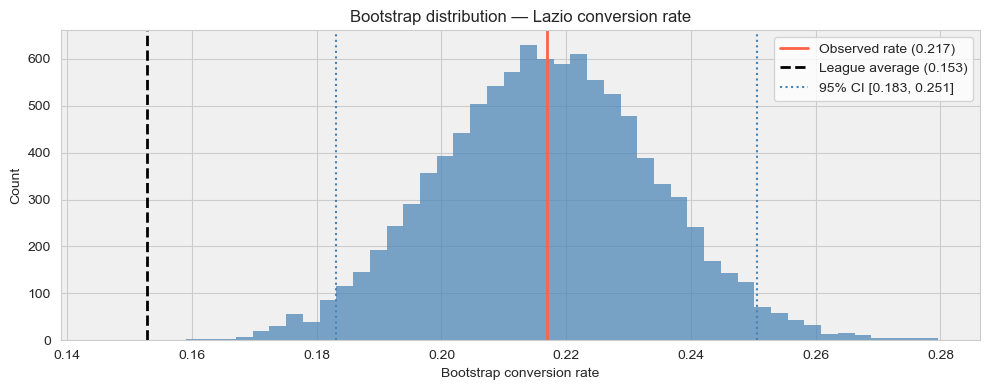

Observed rate:        0.2170
Bootstrap mean:       0.2168
Bootstrap std:        0.0173
95% CI:               [0.1832, 0.2506]
League average:       0.1528
League average in CI: False


In [8]:
np.random.seed(42)
n_bootstrap = 10_000

lazio_matches = serie_a_2425[serie_a_2425['team'] == 'Lazio'].copy()

bootstrap_rates = []
for _ in range(n_bootstrap):
    sample = lazio_matches.sample(n=len(lazio_matches), replace=True)
    rate = sample['yellow_cards'].sum() / sample['fouls_committed'].sum()
    bootstrap_rates.append(rate)

bootstrap_rates = np.array(bootstrap_rates)
ci_low, ci_high = np.percentile(bootstrap_rates, [2.5, 97.5])

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.set_facecolor('#f0f0f0')
    ax.hist(bootstrap_rates, bins=50, color='steelblue', alpha=0.7, edgecolor='none')
    ax.axvline(p_hat, color='tomato', linewidth=2, label=f'Observed rate ({p_hat:.3f})')
    ax.axvline(p_null, color='black', linewidth=2, linestyle='--',
               label=f'League average ({p_null:.3f})')
    ax.axvline(ci_low, color='steelblue', linewidth=1.5, linestyle=':',
               label=f'95% CI [{ci_low:.3f}, {ci_high:.3f}]')
    ax.axvline(ci_high, color='steelblue', linewidth=1.5, linestyle=':')
    ax.set_xlabel('Bootstrap conversion rate')
    ax.set_ylabel('Count')
    ax.set_title('Bootstrap distribution — Lazio conversion rate')
    ax.legend()
    plt.tight_layout()
    plt.show()

print(f"Observed rate:        {p_hat:.4f}")
print(f"Bootstrap mean:       {bootstrap_rates.mean():.4f}")
print(f"Bootstrap std:        {bootstrap_rates.std():.4f}")
print(f"95% CI:               [{ci_low:.4f}, {ci_high:.4f}]")
print(f"League average:       {p_null:.4f}")
print(f"League average in CI: {ci_low <= p_null <= ci_high}")

The bootstrap is computationally heavier than the z-test or the exact binomial: thousands of resamples instead of one formula. As we say when [dealing with yellow cards](https://github.com/pacoraggio/euro-football-discipline-stats/blob/master/notebooks/04_yellow_cards_analysis.ipynb) this is similar to the tradeoff from the permutation test. The logic is the same: flexibility costs compute. On a dataset this size the difference is negligible, but the principle matters: when a simpler model's assumptions hold, use it. When they do not, the bootstrap is there.

The bootstrap distribution is approximately bell-shaped and centred tightly around the observed rate of 0.217. The 95% confidence interval runs from 0.183 to 0.251: we are 95% confident that Lazio's true underlying conversion rate sits somewhere in that range.

The league average of 0.153 is nowhere near the interval. It sits far to the left of the entire bootstrap distribution, which confirms what the proportion tests already told us: Lazio's rate is not consistent with the league average. The confidence interval and the hypothesis test are two sides of the same coin. When the null value falls outside the 95% confidence interval, the two-sided p-value is below 0.05. Both are true here, and by a wide margin.

Notice also that the bootstrap standard deviation (0.0173) is very close to the standard error we computed manually for the z-test (0.0175). This is not a coincidence. When the bootstrap works well, it recovers the same uncertainty estimate as the analytical formula. The fact that they agree here is a validation of both approaches.

The bootstrap adds something the proportion tests cannot: a picture of the full distribution of plausible values. We know Lazio's rate is significantly above average, and we know that "significantly above average" means somewhere between 0.183 and 0.251 with 95% confidence. That range is the practical answer to the question of how unusual Lazio really are.

We now have three tools that agree: z-test, exact binomial, and bootstrap. Time to run them across the full league.


## Full league analysis: which teams stand out?

We have validated the toolkit on Lazio. Now we run the same three tests for every team in the league: z-test for proportions, exact binomial, and bootstrap confidence interval. The reference rate for each test is the league average computed from all other teams, not including the team being tested. This is the same one-versus-rest logic we used in the fouls and yellow cards notebooks.

In [9]:
from discipline_stats import compare_mean_to_threshold

np.random.seed(42)
results_rate = []

for _, row in rate_df.iterrows():
    team_name = row['team']
    n = int(row['total_denominator'])
    k = int(row['total_numerator'])
    p_hat = k / n

    # Reference rate: rest of league
    rest = serie_a_2425[serie_a_2425['team'] != team_name]
    p_ref = rest['yellow_cards'].sum() / rest['fouls_committed'].sum()

    # Z-test
    z, p_z = proportions_ztest(k, n, p_ref)

    # Exact binomial
    p_binom = stats.binomtest(k, n, p_ref, alternative='two-sided').pvalue

    # Bootstrap
    team_data = serie_a_2425[serie_a_2425['team'] == team_name]
    boot_rates = []
    for _ in range(10_000):
        sample = team_data.sample(n=len(team_data), replace=True)
        boot_rates.append(sample['yellow_cards'].sum() / sample['fouls_committed'].sum())
    boot_rates = np.array(boot_rates)
    ci_low, ci_high = np.percentile(boot_rates, [2.5, 97.5])
    ref_in_ci = ci_low <= p_ref <= ci_high

    results_rate.append({
        'team': team_name,
        'n_fouls': n,
        'n_cards': k,
        'rate': round(p_hat, 4),
        'ref_rate': round(p_ref, 4),
        'diff': round(p_hat - p_ref, 4),
        'z_p': round(p_z, 4),
        'binom_p': round(p_binom, 4),
        'ci_low': round(ci_low, 4),
        'ci_high': round(ci_high, 4),
        'ref_in_ci': ref_in_ci,
        'sig_z': p_z < 0.05,
        'sig_binom': p_binom < 0.05
    })

results_rate_df = pd.DataFrame(results_rate).sort_values('rate', ascending=False).reset_index(drop=True)
results_display = results_rate_df.rename(columns={
    'n_fouls': 'Fouls',
    'n_cards': 'Cards',
    'rate': 'Rate',
    'ref_rate': 'Ref rate',
    'diff': 'Diff',
    'z_p': 'p (z-test)',
    'binom_p': 'p (binomial)',
    'ci_low': 'CI low',
    'ci_high': 'CI high',
    'ref_in_ci': 'Ref in CI',
    'sig_z': 'Sig (z)',
    'sig_binom': 'Sig (binom)'
})

results_display

,team,Fouls,Cards,Rate,Ref rate,Diff,p (z-test),p (binomial),CI low,CI high,Ref in CI,Sig (z),Sig (binom)
0,Lazio,424,92,0.2170,0.1498,0.0672,0.0008,0.0002,0.1832,0.2506,False,True,True
1,Fiorentina,440,81,0.1841,0.1513,0.0328,0.0760,0.0622,0.1527,0.2158,False,False,False
2,Parma,405,74,0.1827,0.1515,0.0312,0.1040,0.0831,0.1435,0.2242,True,False,False
3,Monza,511,90,0.1761,0.1515,0.0246,0.1440,0.1229,0.1481,0.2063,True,False,False
4,Como,497,87,0.1751,0.1516,0.0235,0.1689,0.1501,0.1419,0.2122,True,False,False
5,Torino,480,80,0.1667,0.1521,0.0146,0.3915,0.3735,0.1371,0.1972,True,False,False
6,Milan,415,68,0.1639,0.1523,0.0115,0.5256,0.4950,0.1255,0.2041,True,False,False
7,Verona,579,94,0.1623,0.1522,0.0101,0.5082,0.4877,0.1318,0.1952,True,False,False
8,Roma,405,64,0.1580,0.1526,0.0054,0.7645,0.7301,0.1232,0.1954,True,False,False
9,Udinese,536,84,0.1567,0.1526,0.0041,0.7929,0.7642,0.1303,0.1845,True,False,False


The table separates signal from noise. Of the twenty teams in Serie A 2024/25, sixteen sit close enough to the league average that the tests cannot distinguish their rates from random variation. Four teams stand out.

Lazio converts fouls into yellow cards at a rate of 0.217, roughly one foul in every 4.6 results in a booking. The league average is one in 6.5. Both the z-test and the exact binomial agree: this is not a fluke (p < 0.01). The bootstrap confidence interval [0.183, 0.251] sits entirely above the league average of 0.153.

At the other end, Empoli, Bologna, and Napoli foul regularly but collect relatively few cards. Empoli's rate of 0.112 and Bologna's 0.117 are significantly below average by both tests. Napoli fouls less than most sides and still shows up as a significan outlier below the average, converting at 0.111.

Notice that the z-test and the exact binomial always agree on direction and broadly agree on magnitude. They should: with sample sizes between 300 and 550 fouls per team, the normal approximation to the binomial is reliable, and the two tests are equivalent in this regime. The exact binomial is the safer default regardless, because it makes no approximation.

The bootstrap confidence intervals tell the same story as the hypothesis tests but add something the p-values do not: a sense of scale. Lazio's interval is wide (0.068 across), reflecting genuine uncertainty in the point estimate. A p-value of 0.0002 can give a false impression of precision; the interval is the honest version.

What the table cannot tell us is why these teams differ. The rate is a compound signal: team behaviour, referee tendency, and their interaction. We will return to that question in the next section.

## The per-match rate

The proportion tests treated the entire season as a single binomial experiment: $k$ yellow cards in $n$ fouls. That is the ratio-of-totals approach from the measurement section.

The second approach treats each match as an independent observation and works with the distribution of per-match rates: yellow cards divided by fouls committed in that match. This is a different object. A team that consistently converts 15% of its fouls in every match looks identical to one that alternates between 5% and 25%, if you only look at the season aggregate. The per-match distribution can tell them apart.

Two tests are natural for per-match rates. Mann-Whitney makes no assumptions about the shape of the distribution (remember, it asks whether one team's per-match rates tend to be systematically higher or lower than the rest of the league). A t-test makes stronger assumptions (approximately normal per-match rates) but is easier to interpret and gives a useful comparison: if the two tests agree, the normality assumption is probably not hurting us.

In [10]:
serie_a_2425 = serie_a_2425.copy()
serie_a_2425['match_rate'] = serie_a_2425['yellow_cards'] / serie_a_2425['fouls_committed'].replace(0, np.nan)

In [11]:
from scipy.stats import mannwhitneyu, ttest_ind

pm_results = []

for team_name in serie_a_2425['team'].unique():
    team_rates = serie_a_2425.loc[serie_a_2425['team'] == team_name, 'match_rate'].dropna()
    rest_rates = serie_a_2425.loc[serie_a_2425['team'] != team_name, 'match_rate'].dropna()

    _, p_mw  = mannwhitneyu(team_rates, rest_rates, alternative='two-sided')
    _, p_t   = ttest_ind(team_rates, rest_rates, equal_var=False)

    pm_results.append({
        'team':        team_name,
        'mean_rate':   team_rates.mean(),
        'p_mw':        p_mw,
        'p_t':         p_t,
        'sig_mw':      p_mw < 0.05,
        'sig_t':       p_t  < 0.05,
    })

pm_df = pd.DataFrame(pm_results).sort_values('mean_rate', ascending=False).reset_index(drop=True)


In [12]:
display_pm = pm_df.rename(columns={
    'team':      'Team',
    'mean_rate': 'Mean per-match rate',
    'p_mw':      'p (Mann-Whitney)',
    'p_t':       'p (Welch t-test)',
    'sig_mw':    'Sig MW',
    'sig_t':     'Sig t',
})
display_pm[['Team', 'Mean per-match rate', 'p (Mann-Whitney)', 'p (Welch t-test)', 'Sig MW', 'Sig t']]\
    .style.format({'Mean per-match rate': '{:.3f}', 'p (Mann-Whitney)': '{:.4f}', 'p (Welch t-test)': '{:.4f}'})


,Team,Mean per-match rate,p (Mann-Whitney),p (Welch t-test),Sig MW,Sig t
0,Lazio,0.218,0.0003,0.0037,True,True
1,Fiorentina,0.211,0.0139,0.0582,True,False
2,Parma,0.196,0.1049,0.1584,False,False
3,Como,0.187,0.2725,0.2030,False,False
4,Monza,0.183,0.1712,0.2238,False,False
5,Milan,0.180,0.5156,0.4049,False,False
6,Torino,0.175,0.3334,0.4076,False,False
7,Verona,0.174,0.4036,0.4422,False,False
8,Venezia,0.160,0.9437,0.9863,False,False
9,Udinese,0.160,0.6700,0.9900,False,False


The two tests mostly agree, but two teams sit in the gap between them, and that gap is informative.

Lazio, Empoli, Bologna and Napoli are significant under both tests and both measurement approaches. The signal for these teams does not depend on which way we measure the rate or which assumptions we make. That is reassuring.

Fiorentina is flagged by Mann-Whitney (p = 0.014) but not by the t-test (p = 0.058). Mann-Whitney tests rank order: it asks whether Fiorentina's per-match rates tend to sit above those of the rest of the league. The t-test asks whether the means differ, and to answer that question it assumes the per-match rates are approximately normal. When the two tests disagree, it often means the distribution is skewed or has outliers that pull the mean without shifting the bulk of the data. Fiorentina probably has a handful of high-card matches that inflate the mean slightly but are not enough for the t-test to reach significance. Mann-Whitney is the more honest test here.

Lecce is the reverse: the t-test flags it (p = 0.033) while Mann-Whitney does not (p = 0.170). This pattern can arise when a few extreme low-card matches pull the mean down without the bulk of the distribution separating from the rest. In that case, the t-test is reacting to outliers rather than a systematic difference. Mann-Whitney, which ignores the magnitude of the gap and only uses ranks, is again the more conservative and more appropriate choice.

The lesson is not that one test is always better than the other. It is that disagreement between them is a signal worth investigating. For the teams that matter most -- Lazio above and Empoli, Bologna, Napoli below -- the conclusion is the same regardless of which test we use or which measurement approach we take.

## Across leagues

So far we have worked entirely within Serie A. Every comparison has been one team against the rest of the same league, in the same season, facing the same pool of referees. That shared context is what makes the within-league results interpretable as a team signal.

Cross-league comparison is a different problem. If Serie A has a higher conversion rate than the Premier League, there are at least three possible explanations: Serie A players commit fouls that referees are more likely to book; Serie A referees have a lower threshold for issuing cards; or some combination of both. The data cannot separate these. What it can do is describe the difference and give us an honest measure of its size.

>We will compute the crude rate for each league and run a proportion test comparing each league against the rest. The interpretation requires care: a significant result tells us the rates differ, not why.

In [14]:
all_2425 = team_matches[
    (team_matches['season'] == '2425') &
    (team_matches['season_status'] == 'complete')
].copy()

league_rates = (
    all_2425.groupby('league')
    .apply(lambda g: pd.Series({
        'yellow_cards':   g['yellow_cards'].sum(),
        'fouls':          g['fouls_committed'].sum(),
        'crude_rate':     g['yellow_cards'].sum() / g['fouls_committed'].sum(),
    }))
    .reset_index()
    .sort_values('crude_rate', ascending=False)
)

league_rates['fouls_per_card'] = league_rates['fouls'] / league_rates['yellow_cards']

print(league_rates.to_string(index=False))

        league  yellow_cards  fouls  crude_rate  fouls_per_card
Premier_League        1539.0 8385.0    0.183542        5.448343
       La_Liga        1703.0 9398.0    0.181209        5.518497
    Bundesliga        1176.0 6532.0    0.180037        5.554422
       Ligue_1        1147.0 7349.0    0.156076        6.407149
       Serie_A        1452.0 9501.0    0.152826        6.543388


In [16]:
league_prop_results = []

for _, row in league_rates.iterrows():
    league_name = row['league']
    k = int(row['yellow_cards'])
    n = int(row['fouls'])
    rest = all_2425[all_2425['league'] != league_name]
    p_ref = rest['yellow_cards'].sum() / rest['fouls_committed'].sum()

    z, p_z = proportions_ztest(k, n, p_ref)
    p_binom = stats.binomtest(k, n, p_ref, alternative='two-sided').pvalue

    league_prop_results.append({
        'league':         league_name,
        'crude_rate':     row['crude_rate'],
        'fouls_per_card': row['fouls'] / row['yellow_cards'],
        'p_z':            p_z,
        'p_binom':        p_binom,
        'sig':            p_z < 0.05,
    })

league_prop_df = pd.DataFrame(league_prop_results)

display(league_prop_df.rename(columns={
    'league':         'League',
    'crude_rate':     'Crude rate',
    'fouls_per_card': 'Fouls per card',
    'p_z':            'p (z-test)',
    'p_binom':        'p (exact binomial)',
    'sig':            'Significant',
}).style.format({'Crude rate': '{:.3f}', 'Fouls per card': '{:.1f}', 'p (z-test)': '{:.4f}', 'p (exact binomial)': '{:.4f}'}))


,League,Crude rate,Fouls per card,p (z-test),p (exact binomial),Significant
0,Premier_League,0.184,5.4,0.0001,0.0001,True
1,La_Liga,0.181,5.5,0.0005,0.0003,True
2,Bundesliga,0.180,5.6,0.0167,0.0145,True
3,Ligue_1,0.156,6.4,0.0000,0.0001,True
4,Serie_A,0.153,6.5,0.0000,0.0000,True


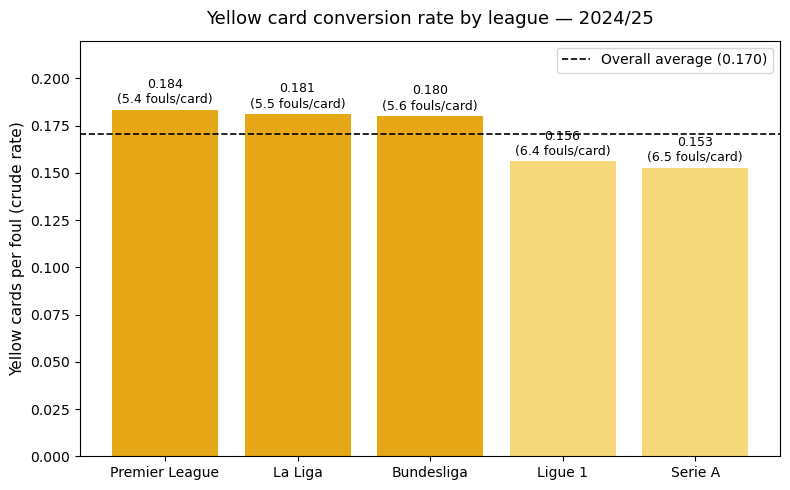

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

overall_rate = all_2425['yellow_cards'].sum() / all_2425['fouls_committed'].sum()
league_labels = league_prop_df['league'].str.replace('_', ' ')
colours = ['#e6a817' if r > overall_rate else '#f5d87a' for r in league_prop_df['crude_rate']]


bars = ax.bar(league_labels, league_prop_df['crude_rate'], color=colours)

ax.axhline(overall_rate, color='black', linewidth=1.2, linestyle='--',
           label=f'Overall average ({overall_rate:.3f})')

for bar, rate, fpc in zip(bars, league_prop_df['crude_rate'], league_prop_df['fouls_per_card']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{rate:.3f}\n({fpc:.1f} fouls/card)', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Yellow cards per foul (crude rate)', fontsize=11)
ax.set_title('Yellow card conversion rate by league — 2024/25', fontsize=13, pad=12)
ax.set_ylim(0, 0.22)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


All five leagues differ significantly from the pooled average of the other four. But before reading too much into the p-values, look at the rates themselves.

The five leagues split into two rough groups. Premier League, La Liga and Bundesliga cluster between 0.180 and 0.184, roughly one booking for every 5.5 fouls. Ligue 1 and Serie A sit lower, at 0.156 and 0.153. The gap between the two groups is about three percentage points. With sample sizes of 6,000 to 9,500 fouls per league, even small differences will produce very small p-values. Significance here is almost guaranteed; the question worth asking is whether the difference is meaningful.

What the table cannot tell us is where this gap comes from. A higher conversion rate in the Premier League could mean that Premier League players commit fouls that are more likely to attract a card, maybe more reckless challenges, more dissent, more professional fouls in dangerous positions. It could equally mean that Premier League referees apply a stricter threshold. Or both. The compound signal problem that appeared at team level reappears here at league level, and the data alone cannot decompose it.

The honest reading is this: the rates differ, the difference is consistent across both tests, and the direction is stable. What drives it is a question for a different dataset one that can hold referee identity constant across leagues, or track the same players moving between competitions.

## Back to the scatter plot

When performing the [yellow card analysis](https://github.com/pacoraggio/euro-football-discipline-stats/blob/master/notebooks/04_yellow_cards_analysis.ipynb), we produces a scatter plot that coloured teams by how far they sat from the diagonal the line of proportional behaviour where more fouls produce proportionally more cards. Two teams sat well above it: Lazio collected far more cards than their foul count would suggest. Two sat well below it: Bologna and Empoli fouled regularly but accumulated few bookings.

That plot was a visual prompt, not a test. The question was whether the pattern would survive scrutiny. It has.

Lazio's conversion rate of 0.217 is the highest in the league. Both proportion tests and Mann-Whitney flag it as significantly above average. The bootstrap confidence interval [0.183, 0.251] sits entirely above the league rate of 0.153. Whatever is driving Lazio's bookings, e.g. playing style, referee perception, positional aggression, it is consistent enough across 38 matches to show up clearly in every test we ran.

Bologna and Empoli are the mirror image. Both sit significantly below the league average under all three approaches: z-test, exact binomial, and Mann-Whitney. Bologna converts at 0.117 and Empoli at 0.112. In a league where the average foul produces a card roughly one time in 6.5, these teams are closer to one in nine.

Napoli rounds out the picture. It did not appear in the original scatter plot discussion (its foul count is low enough that it did not stand out visually) but the rate tests surface it clearly as a below-average outlier, significant under all three methods.

The scatter plot asked the right question. The tests confirmed the answer.

## Conclusion

We started with a scatter plot anomaly and ended with a consistent finding across three tests and two measurement approaches. Lazio converts fouls into yellow cards at a rate significantly above the Serie A average; Bologna, Empoli and Napoli sit significantly below it. Sixteen teams are indistinguishable from the league norm. The result is stable: it does not depend on whether we measure the rate as a season aggregate or as a distribution of per-match ratios, and it does not depend on whether we use a parametric test or a non-parametric one.

What we cannot say is why. The conversion rate is a compound signal. It folds together how a team fouls, how referees perceive those fouls, and the interaction between the two. A high rate could mean a team commits fouls in dangerous positions, or with dissent, or against high-profile opponents -- all of which attract cards. It could also mean that the referees assigned to a team's matches happen to be stricter. The data does not separate these explanations.

The cross-league comparison sharpens the limitation. Premier League, La Liga and Bundesliga cluster around 0.181 to 0.184; Ligue 1 and Serie A sit lower at 0.156 and 0.153. The gap is statistically significant and consistent, but it is a compound of team behaviour and referee culture in unknown proportions. A higher rate in the Premier League does not mean Premier League players foul more recklessly. It might. We do not know.

Two questions follow naturally from here. The first is temporal: are Lazio's rate and Bologna's rate stable across seasons, or are they artefacts of a single year? A team that appears as an outlier in one season but not in others is a weaker signal than one that sits consistently above or below the average. The second is structural: can we isolate the referee contribution? Referee assignment data, or a dataset that tracks the same players across national and international competitions, would let us begin to decompose the signal. Both questions are tractable. Both are for the next notebook.


---

## Appendix: a note on Donald Ransom Whitney

In the Mann-Whitney section we described Whitney as Mann's doctoral student. A more precise account: Whitney co-published the famous 1947 paper "On a Test of Whether One of Two Random Variables Is Stochastically Larger than the Other" with Mann while still a doctoral candidate at Ohio State University. He completed his PhD two years later, in 1949, with a thesis titled "A Comparison of the Power of Nonparametric Tests and Tests Based on the Normal Distribution Under Nonnormal Alternatives" — an extension of the same work rather than its source.

So he published the result that would carry his name for the rest of statistical history before he had even finished his doctorate. His supervisor presumably signed off on the thesis without excessive scrutiny. Apparently, some things never change in academia.

Source: Mathematics Genealogy Project, https://www.mathgenealogy.org/id.php?id=10179